# Problem Set 2, Exercise 1 
Pryce Davies and Richard Chen.  
Taken from ps2_ex1 by Conroy Lau. 

In [1]:
import os
import copy
import random
import array
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from numpy.linalg import norm
from numpy import ndarray
from cyipopt import minimize_ipopt

# Exercise 1.1
## Code from ps2_ex1 notebook


### Primitive

The object `dgp` stores the model primitives. 

Since we parameterize the utility functions completely by $\theta$, the object is going to store $\theta$ instead of the entire vector of utilities.

In [2]:
class dgp:
    """Creates the primitives of the dynamic discrete choice model.
        
        Parameters
        ----------
        β : `float`
            The discount factor.
        u : `nd_array`
            A matrix of utility over all the states and choices.
        f : `nd_array`
            Transition matrices for all the actions.
        J : `int`
            Number of actions.
        dx : `int`
            Number of states.
    """
    def __init__(
        self, 
        β: float,
        u: ndarray,
        F: ndarray,
        dx: int,
        J: int):
        
        self.β = β
        self.u = u
        self.F = F
        self.dx = dx
        self.J = J

In [3]:
β = 0.95
θ = [-0.2, 5]
dx = 10
J = 2

Next, we can let `utility` be the deterministic part of the utility function that depends on our pre-defined parameters $\theta$, as well as the choice and state. Since the deterministic part of the utility is completely characterized by $\theta$, $x$, and $a$, we can compute them all in advance.

In [4]:
def utility(
    x: int, 
    a: int,
    θ: list):
    """Calculates the utility at a given action and state.
        
        Parameters
        ----------
            x : `int`
                State.
            a : `int`
                Action.
            θ : `list`
                Utility parameters.
    """
    
    if a == 0:
        u = x * θ[0] + θ[1]
    elif a == 1:
        u = 0
        
    return u

def utility_matrix(
    dx: int,
    J: int,
    θ: list):
    """Returns the matrix of utilites over all states and choices.
        
        Each row corresponds to a state.
        
        Each column corresponds to an action.
        
        Parameters
        ----------
            dx : `int`
                Number of states.
            J : `int`
                Number of actions.
            θ: `list`
                Utility parameters.
    """
    
    umat = np.zeros((dx, J))
    
    for a in range(J):
        for x in range(dx):
            umat[x, a] = utility(x, a, θ)
            
    return umat

umat = utility_matrix(dx, J, θ)


Now, let's create the transition matrix, i.e., $\mathrm{Pr}[dx_{t+1}|x_t, a_t = j, \varphi]$.

In [5]:
def transition(
    f: list,
    dx: int):
    """Creates the transition matrices.
        
       This function creates the transition matrices for both actions.
       The parameter `f` is only relevant for constructing the 
       transition matrix for the action j = 0.
       
       Parameters
       ----------
           f : `list`
               Parameters for the multinomial distribution for j = 0.
           dx : `int`
               Number of states.
    """
    
    # Initialize the two matrices
    F0 = np.zeros((dx, dx))
    F1 = copy.copy(F0)
    
    # Transition matrix for maintaining the engine
    for i in range(dx):
        if i < dx - 2:
            F0[i, i] = f[0]
            F0[i, i + 1] = f[1]
            F0[i, i + 2] = 1 - f[0] - f[1]
        elif i == dx - 2:
            F0[i, i] = f[0]
            F0[i, i + 1] = 1 - f[0]
        else:
            F0[i, i] = 1
    
    # Transition matrix for replacing the engine
    F1[:, 0] = 1
        
    return F0, F1

f = [0.3, 0.6]
F = transition(f, dx)


In [6]:
primitive = dgp(β, umat, F, dx, J)


### Bellman equation representation

**Reference: chapter 2.3.1.3**

- Let $\mathrm{Pr}[dx_{t+1}|x_t, a_t = j, \varphi]$ be the transition probability.
- Let $\overline{v}_j(x_t; \theta, \varphi)$ be the deterministic part of the value function for choosing choice $j$ at state $x_t$. Then, we can write
  $$
    \overline{v}_j(x_t; \theta, \varphi)
    = \overline{u}_j(x_t; \theta) + 
        \beta \int 
            \ln \left( \sum_{k \in \mathcal{J}}
                \exp\{\overline{v}_k(x_{t+1}; \theta, \varphi)\}
                \right) \mathrm{Pr}[dx_{t+1}|x_t, a_t = j, \varphi].
  $$
- The function `csvf_state` codes the choice-specific value function at state `x` with the given vector of value functions `V`.

### Fixed point representation


- Let $\overline{w}(x_t; \theta, \varphi) \equiv \ln(\sum_{k \in \mathcal{J}} \exp\{\overline{v}_k(x_k; \theta, \varphi)\})$.
- The fixed-point equation can be written as follows:
  $$
      \begin{pmatrix}
          \overline{v}_j(1; \theta, \varphi) \\ 
          \vdots \\
          \overline{v}_j(X; \theta, \varphi)
      \end{pmatrix}
      = 
      \begin{pmatrix}
          \overline{u}_j(1; \theta) \\ 
          \vdots \\ 
          \overline{u}_j(X; \theta)
      \end{pmatrix}
      + \beta \mathbf{P}[x_{t+1} | x_t, a_t; \varphi]
      \begin{pmatrix}
          \overline{w}(1; \theta, \varphi) \\ 
          \vdots \\ 
          \overline{w}(X; \theta, \varphi)
      \end{pmatrix},
  $$
  for each $j \in \mathcal{J}$.
- The above is a fixed-point equation. For a given guess of $\{\overline{w}(x; \theta, \varphi)\}_{x \in \mathcal{X}}$, one can update $\{\overline{v}_j(x; \theta, \varphi)\}_{j \in \mathcal{J}, x \in \mathcal{X}}$, and then update $\{\overline{w}(x; \theta, \varphi)\}_{x \in \mathcal{X}}$. One can update this via the fixed point iteration procedure.
- The function `vf` computes $\{\overline{w}(x; \theta, \varphi)\}_{x \in \mathcal{X}}$ for a given of $\{\overline{v}_j(x; \theta, \varphi)\}_{j \in \mathcal{J}, x \in \mathcal{X}}$.

In [7]:
def csvf_state(dgp, V, x):
    """Choice-specific value function at a particular state.
        
        Parameters
        ----------
            dgp : `dgp`
                The primitive of the DDC model.
            V : `ndarray`
                A vector of value function.
            x : `int`
                State.
    """
    
    w = [dgp.u[x, a] + dgp.β * np.matmul(dgp.F[a][x, :], V) for a in range(dgp.J)]
    
    return w

def csvf(dgp, V):
    """Choice-specific value functions across all states.
    
        The function stacks the output of `csvf_state` over all states.
        
        Parameters
        ----------
            dgp : `dgp`
                The primitive of the DDC model.
            V : `ndarray`
                A vector of value function.
    """
    
    wmat = np.zeros((dgp.dx, dgp.J))
    
    for x in range(dgp.dx):
        wmat[x, :] = csvf_state(dgp, V, x)    
    
    return wmat

def vf(w):
    """Computes the integrated value function.
    
        This function computes the integrated value function based on the 
        choice-specific value functions.
        
        Parameters
        ----------
            w : `ndarray`
                A vector of value functions.
    """
    
    # Extract the maximum value for numerical stability (log-sum-exp trick)
    # This prevents overflow when exponentiating large values
    wmax = np.amax(w)
    
    # Compute log(exp(w_0 - max) + exp(w_1 - max))
    # This is numerically stable because the exponentials are now of small values
    v = np.log(np.exp(w[:, 0] - wmax) + np.exp(w[:, 1] - wmax))
    
    # Add back the maximum value to recover the true log-sum-exp:
    # log(exp(w_0) + exp(w_1)) = log(exp(w_0 - max) + exp(w_1 - max)) + max
    v += wmax
    
    return v

In [8]:
def vfi(dgp, ϵ = 1e-8):
    """Value function iteration.
        
        Takes the DGP object and returns the fixed-point of the value function equation.
        
        This function implements the fixed-point iteration algorithm described in the 
        "Fixed point representation" section. It solves the Bellman equation by iteratively
        updating the value function until convergence.
        
        Algorithm steps:
        1. Start with an initial guess V0 for the integrated value function w(x)
        2. Compute choice-specific values: w = csvf(dgp, V0) gives v_j(x) for all choices j
        3. Compute integrated value: V1 = vf(w) gives w(x) = ln(sum_j exp{v_j(x)})
        4. Check convergence: if ||V0 - V1|| < ϵ, we've found the fixed point
        5. Otherwise, update V0 = V1 and repeat
        
        Parameters
        ----------
            dgp : `dgp`
                The primitives of the DDC model.
            ϵ : `float`
                The tolerance level.
    """
    
    # Initialize - construct utility, transition matrices, and value function
    V0 = np.zeros(dgp.dx)

    # Iterate until convergence
    gap = 10000.
    iter = 1
    while gap > ϵ:
        w = csvf(dgp, V0)
        V1 = vf(w)
        gap = norm(V0 - V1)
        V0 = V1
        iter += 1
        
    return V0

We can get the value function using the model primitives as follows.

In [9]:
v_true = vfi(primitive)


### Conditional choice probability

- Under the assumption that $\epsilon_{jt}$ follows a mean 0 T1EV distribution, the conditional choice probability of choosing $j \in \mathcal{J}$ at state $x_t \in \mathcal{X}$ is
  $$
        \mathrm{Pr}[a_t = j | x_t; \theta, \varphi]
        = 
        \frac{\exp\{\overline{v}_j(x_t; \theta, \varphi)\}}{
        \sum_{k\in \mathcal{J}} \exp\{\overline{v}_k(x_t; \theta, \varphi)\}}.
  $$

In [10]:
def prob_from_dgp(dgp, V):
    """Conditional choice probability of maintaining the engine.
    
        Compute the conditional choice probability for maintaining the engine.
        
        Parameters
        ----------
            dgp : `dgp`
                The primitives of the DDC model.
            V : `ndarray`
                A vector of value functions.
    """
    
    # Compute the choice probability and take the difference
    w = csvf(dgp, V)
    
    # Extract the maximum value for numerical stability (softmax trick)
    # This prevents overflow when exponentiating
    wmax = np.amax(w)
    wdifexp = np.exp(w - wmax)
    
    # Compute the conditional choice probability
    prob = np.zeros((dgp.dx, dgp.J))
    wsum = np.sum(wdifexp, axis = 1)
    for a in range(dgp.J):
        prob[:, a] = wdifexp[:, a]/wsum
        
    return prob

We can compute the probability of maintaining the engine as follows.

In [11]:
prob_true = prob_from_dgp(primitive, v_true)
prob_maintain_true = prob_true[:, 0]

### Simulate data code

With the functions for the value function and the primitives of the models defined, we are able to simulate data from it. 

Let there be $N$ (independent) buses and $T$ periods. The following function simulates data and stores the results as a dataframe.

In [12]:
def draw(dgp, V, N, T):
    """Simulate Rust data.
    
        Draw data with N buses and T periods based on the `dgp` and `ddc` objects.
        
        Parameters
        ----------
            dgp : `dgp`
                The primitives of the DDC model.
            V : `ndarray`
                A vector of value functions.
            N : `int`
                Number of buses.
            T : `int`
                Number of periods.
    """
    action = [] #np.zeros((N, T - 1))
    state = []
    ids = []
    ts = [] 
    
    for i in range(N):
        # Initialize arrays for this bus i
        ai = np.zeros(T)        # Action history for bus i: [t=0, t=1, ..., t=T-1]
        si = np.zeros(T, dtype=int)  # State history for bus i
        si[0] = 0               # All buses start at state 0 (lowest mileage)
        ai[0] = None            # No action at t=0 (mileage hasn't accumulated yet)
        
        for t in range(T - 1):
            # ===== STEP 1: STATE TRANSITION =====
            # The state evolves based on the action taken at time t
            
            uf = np.random.uniform()  # Draw uniform random number for state transition
            
            # Condition: Maintain action (a=0) OR first period (t=0)
            if (t > 0) & (ai[t] == 0) | (t == 0):
                st = si[t]
                f0 = dgp.F[0][st]  # Transition probabilities for maintain action from state st
                
                # Implement the multinomial distribution for state transitions
                # The transition matrix has structure: stay with prob f0[st], 
                # move +1 with prob f0[st+1], move +2 with prob (1-f0[st]-f0[st+1])
                
                if si[t] < dgp.dx - 2:  # Not in last two states
                    if uf < f0[st]:
                        si[t + 1] = si[t]           # Stay in same state
                    elif (uf >= f0[st]) & (uf < (f0[st] + f0[st + 1])):
                        si[t + 1] = si[t] + 1       # Move up one state
                    else:
                        si[t + 1] = si[t] + 2       # Move up two states (highest increment)
                        
                elif si[t] == dgp.dx - 2:  # Second-to-last state
                    if uf < f0[st]:
                        si[t + 1] = si[t]           # Stay
                    else:
                        si[t + 1] = si[t] + 1       # Move to last state
                else:
                    # Already at maximum state
                    si[t + 1] = si[t]               # Stay at max state
                    
            elif ai[t] == 1:
                # Replace action (a=1): Reset the bus to state 0
                si[t + 1] = 0
            
            # ===== STEP 2: CHOICE SIMULATION =====
            # Observe the state at t+1 and choose the action that maximizes
            # utility (deterministic value + random shock)
            
            # Get the choice-specific values (deterministic components) at the new state
            us = csvf_state(dgp, V, int(si[t + 1]))
            
            # Add Type-1 Extreme Value (Gumbel) shocks to each choice
            # Location parameter -.577 (Euler-Mascheroni constant) makes the mean 0
            us += np.random.gumbel(-.577, size=dgp.J)
            
            # Choose the action with the highest utility (deterministic + stochastic)
            ai[t + 1] = np.argmax(us)
        
        # ===== STEP 3: AGGREGATE DATA =====
        # Collect data from this bus and add to overall arrays
        state = np.concatenate((state, si))
        action = np.concatenate((action, ai))
        ids = np.concatenate((ids, np.repeat(i + 1, T)))  # Bus ID is 1-indexed
        ts = np.concatenate((ts, range(0, T)))            # Time periods 0, 1, ..., T-1
    
    # Create DataFrame with columns: bus ID, time, action, state
    df = pd.DataFrame({'i': ids, 't': ts, 'action': action, 'state': state})
    
    return df

In [13]:
def estimate_ccp(data, dgp):
    """Estimates conditional choice probability of maintaining the engine
        This is estimated using the simple frequency estimator.
        
        Parameters
        ----------
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
    """
    
    phat = np.zeros((dgp.dx, dgp.J))
    
    for x in range(dgp.dx):
        data_x = data.loc[(data.t > 0) & (data.state == x)]
        n_obs = len(data_x)
        
        if n_obs > 0:
            for a in range(dgp.J):
                phat[x, a] = np.mean(data_x.action == a)
        else:
            phat[x, :] = phat[x-1, :]
            print(f"Warning: State {x} has no observations, imputing from state {x-1}")
    
    # Add epsilon to prevent zeros and renormalize 
    epsilon = .01
    phat = phat + epsilon
    phat = phat / phat.sum(axis=1, keepdims=True)
    
    return phat

In [14]:
def estimate_transition_maintain(data, dgp):
    """Estimated the transition matrix for maintaining bus engine.
        
        Parameters
        ----------
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
    """
    
    # Estimate Δstate for each of the states
    data_tmp = copy.copy(data)
    data_tmp['state_shift'] = data_tmp.groupby('i')['state'].shift(-1)
    data_tmp['state_dif'] = data_tmp['state_shift'] - data_tmp['state']
    data_sub = data_tmp.loc[(data_tmp.action == 0) & (data_tmp.t != max(data_tmp.t))]
    
    # Construct the transition matrix for a = 0
    unique_dif = pd.unique(data_sub['state_dif'])
    probs = np.zeros(len(unique_dif))
    for idu, val in enumerate(unique_dif):
        probs[idu] = np.mean(data_sub['state_dif'] == val)
        
    return probs


def estimate_transition(data, dgp):
    """Estimate the transition matrix based on the data.
    
        Parameters
        ----------
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
    """
    
    # Estimate the parameters of the multinomial distribution
    maintain_prob = estimate_transition_maintain(data, dgp)
    
    # Construct the transition matrix
    transition_mat = transition(maintain_prob[range(dgp.J)], dgp.dx)
    
    return transition_mat

## Plots by $\beta, \: \theta_1,\: \theta_2$
For some different combinations of model parameters (β, θ1, and θ2), plot the implied true conditional choice probability of choosing to maintain the engine (i.e., Choice 1) for each state xt. Compare your plots across different values of β, θ1, and θ2. How do plots change as you vary each of those model parameters? Do the patterns you observe make sense?

In [15]:
'''
Initialize list of parameters to plot
'''
beta_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95,.99]
theta_variations = [[-2, 5],[-1, 5],[-0.5, 5], [-0.2, 5],[0, 5], [-0.2, 1],[-0.2, 2.5],[-0.2, 5],[-0.2, 7.5],[-0.2, 10]]
beta_fixed = 0.95
theta_fixed = [-0.2, 5]
dx_fixed = 10
J_fixed = 2

'''
Create list of primitives
'''
param_list = []
for beta in beta_values:
    param_list.append({"beta": beta, "theta": theta_fixed, "dx": dx_fixed, "J": J_fixed})
for theta in theta_variations:
    param_list.append({"beta": beta_fixed, "theta": theta, "dx": dx_fixed, "J": J_fixed})
param_list

for params in param_list:
    params['u'] = utility_matrix(params['dx'], params['J'], params['theta'])

for params in param_list:
    params['F'] = transition([0.3, 0.6],params['dx'])

dgp_list = [
    dgp(params['beta'], params['u'], params['F'], params['dx'], params['J'])
    for params in param_list
]

'''
Compute implied true CCP for each state for each set of parameters
'''
v_list =[
vfi(primitive)
for primitive in dgp_list
]

results = []
for i in range(21):
    result = prob_from_dgp(dgp_list[i],v_list[i])
    results.append(result[:,0])

'''
Create Dataframe
'''

# Create base DataFrame
df = pd.DataFrame({
    'beta': [params['beta'] for params in param_list],
    'theta_0': [params['theta'][0] for params in param_list],
    'theta_1': [params['theta'][1] for params in param_list],
})
result_df = pd.DataFrame(results, columns=[f'state_{i}' for i in range(10)])
df = pd.concat([df, result_df], axis=1)

df= df.melt(
    id_vars=['beta', 'theta_0', 'theta_1'],
    value_vars=[f'state_{i}' for i in range(10)],
    var_name='state',
    value_name='value'
)
df['state'] = df['state'].str.extract('(\\d+)').astype(int)


df_beta = df[(df['theta_0']==-0.2) & (df['theta_1']==5)]
df_theta_0 = df[(df['beta']==beta_fixed) & (df['theta_1']==5)]
df_theta_1 = df[(df['beta']==beta_fixed) & (df['theta_0']==-0.2)]


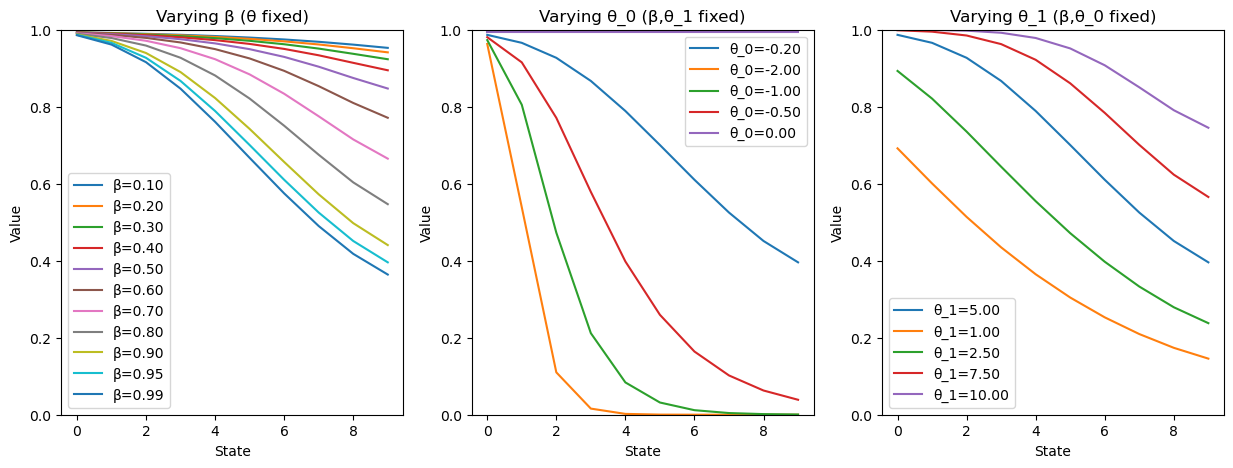

In [16]:
'''
Plot
'''
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for beta in df_beta['beta'].unique():
    data = df_beta[df_beta['beta'] == beta]
    axes[0].plot(data['state'], data['value'], label=f'β={beta:.2f}')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Value')
axes[0].set_title('Varying β (θ fixed)')
axes[0].set_ylim(0, 1)

axes[0].legend()

for theta0 in df_theta_0['theta_0'].unique():
    data = df_theta_0[df_theta_0['theta_0'] == theta0]
    axes[1].plot(data['state'], data['value'], label=f'θ_0={theta0:.2f}')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Value')
axes[1].set_title('Varying θ_0 (β,θ_1 fixed)')
axes[1].set_ylim(0, 1)
axes[1].legend()

for theta1 in df_theta_1['theta_1'].unique():
    data = df_theta_1[df_theta_1['theta_1'] == theta1]
    axes[2].plot(data['state'], data['value'], label=f'θ_1={theta1:.2f}')
axes[2].set_xlabel('State')
axes[2].set_ylabel('Value')
axes[2].set_title('Varying θ_1 (β,θ_0 fixed)')
axes[2].set_ylim(0, 1)
axes[2].legend()

# Exercise 1.2



**Reference: Chapter 2.3.2**

- Let $\widehat{\text{Pr}}[a_t = j|x_t]$ and $\widehat{v}_j(x_t)$ be the sample analogue of $\text{Pr}[a_t = j|x_t; \theta, \varphi]$ and $\overline{v}_j(x_t; \theta, \varphi)$ respectively. As noted in footnote 20, we do not index the sample analogue by $\theta$ and $\varphi$ because we estimate them from data.
- Then, the sample analogue of the conditional choice probability can be written as
  $$
    \widehat{\mathrm{Pr}}[a_t = j | x_t]
    = \frac{\exp(\widehat{v}_j(x_t))}{\sum_{k \in \mathcal{J}} \exp(\widehat{v}_k(x_t))}.
  $$
- Let $J$ be the reference choice, or outside option, in which we normalize $\overline{v}_J(x_t; \theta, \varphi) = 0$. Then, using the above sample analogue representation, we can write
  $$
    \ln \left(
        \frac{\widehat{\text{Pr}}(a_t = j|x_t)}{\widehat{\text{Pr}}(a_t = J|x_t)}
        \right)
        = \widehat{v}_j(x_t) - \underbrace{\widehat{v}_J(x_t)}_{\text{$=0$ by normalization}}.
  $$
- As a result, the maximum-likelihood estimator would proceed with the objective function
  $$
    \sum_t \sum_{j \in \mathcal{J}} 
      \mathbf{1}(a_t = j|x_t)
      \log \left\{
        \frac{\exp(\overline{\widehat{v}}_j(x_t; \theta, \varphi))}{\sum_{k \in \mathcal{J}} \exp( \overline{\widehat{v}}_k(x_t; \theta, \varphi))}
      \right\}
  $$
  where
  $$
    \overline{\widehat{v}}_j(x_t; \theta, \varphi)
      - \overline{\widehat{v}}_J(x_t; \theta, \varphi)
      = \overline{u}_j(x_t; \theta) - \overline{u}_J(x_t; \theta)
      + \beta \int \ln \left(
          \sum_{k \in \mathcal{J}}
              \exp(\widehat{v}_k(x_{t+1}))
          \right)
          \left\{
            \mathrm{Pr}(dx_{t+1}|x_t, a_t = j, \varphi)
            - \mathrm{Pr}(dx_{t+1}|x_t, a_t = J, \varphi)
          \right\}.
  $$

Complete the functions csvf from ccp, likelihood two step ccp, and two step ccp under “Estimation 2: Conditional choice probability inversion” section of the Jupyter Notebook to implement the estimation method illustrated above. 

In [17]:
def csvf_from_ccp(dgp, phat):
    """Estimates choice-specific value function from choice probabilities.
    
        The choice-specific value function of the last action is normalized to 0.
                
        Parameters
        ----------
        dgp : `dgp`
            The primitives of the DDC model.
        phat : `ndarray`
            The matrix of estimated choice probabilities.
    """
    ep = 1e-8
    phat_clipped = np.clip(phat, ep,None)
    csvf = np.zeros((dgp.dx, dgp.J))
    csvf[:,1] = 0.0
    csvf[:,0] = np.log(phat_clipped[:, 0]) - np.log(phat_clipped[:, 1])
    return csvf

    # implement this function

In [18]:
def likelihood_two_step_ccp(θ, data, dgp, phat):
    """
    The likelihood function for the two-step method.
        
        Parameters
        ----------
        θ : `list`
            The utility parameters.
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
        phat : `ndarray`
            The matrix of estimated choice probabilities.
    """
    try:
        # Step 1: Invert CCPs to get choice-specific values 
        csvf = csvf_from_ccp(dgp, phat)
    
        # Step 2: Compute integrated value
        wmax = np.amax(csvf)
        w_hat = np.log(np.exp(csvf[:, 0] - wmax) + np.exp(csvf[:, 1] - wmax)) + wmax
        Ew_0 = dgp.F[0] @ w_hat
        Ew_1 = dgp.F[1] @ w_hat
    
        # Step 3: Compute utilities under the estimated θ
        u_mat = utility_matrix(dgp.dx, dgp.J, θ)
        u_diff = u_mat[:,0]-u_mat[:,1]

        # Step 4: Compute implied exp(v_bar)
        v_bar = np.zeros((dgp.dx,dgp.J))
        v_bar[:,0] = np.exp(u_diff+dgp.β * (Ew_0-Ew_1))
        v_bar[:,1] = np.exp(0)

    # Step 5: Compute implied choice probs from v_bar
        prob = np.zeros((dgp.dx, dgp.J))
        vsum = np.sum(v_bar, axis = 1)
        for a in range(dgp.J):
            prob[:, a] = v_bar[:, a]/vsum
        
    # Step 6: Compute likelihood of data (function defined earlier in code)
        l = likelihood(data, dgp, prob)

        if np.isfinite(l):
            return l
        else:
            return 1e10
            
    except Exception as e:
            return 1e10
    
    
def two_step_ccp(data, dgp):
    """
    The two-step CCP approach.

        Parameters
        ----------
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
    """
    phat = estimate_ccp(data, dgp)
    def ll(x):
        return likelihood_two_step_ccp(x, data, dgp, phat)
    θ = minimize(ll, [0.1, 0.1])
    return θ


# Exercise 1.3


Choose your true model parameters and simulate data using \texttt{draw} function in the Jupyter
Notebook. Use the choice probability inversion method you implemented in Part 2 to estimate
$\theta=(\theta_1,\theta_2)$ and plot the implied conditional choice probabilities. How do they compare to your
true values of $\theta$ and the corresponding true conditional choice probabilities?

In [19]:
'''
Simulate Data using New Parameters
'''
# Set Parameters
N = 300
T = 300
f = [0.3, 0.6]
F = transition(f, dx)
β = 0.95
θ_sim = [-.1, 4]  
dx = 10
J = 2

# create new utility matrix and value functions
umat_sim = utility_matrix(dx, J, θ_sim)
primitive_sim = dgp(β, umat_sim, F, dx, J)
v_sim = vfi(primitive_sim)

# Simulate new data
np.random.seed(100)
df = draw(primitive_sim, v_sim, N, T)

In [31]:
'''
Estimate thetas from data using ccp inversion 
'''
# Estimate Thetas
primitive_sim.F = estimate_transition(df, primitive_sim)
start_time = time.perf_counter()
ccp_out = two_step_ccp(df, primitive_sim)
end_time = time.perf_counter()
print(f"True theta: {θ_sim}")
print(f"Estimated theta: {ccp_out.x}")
elapsed_time = end_time - start_time
print(f"Execution time: {elapsed_time:.4f} seconds")

True theta: [-0.1, 4]
Estimated theta: [0.1 0.1]
Execution time: 0.0158 seconds


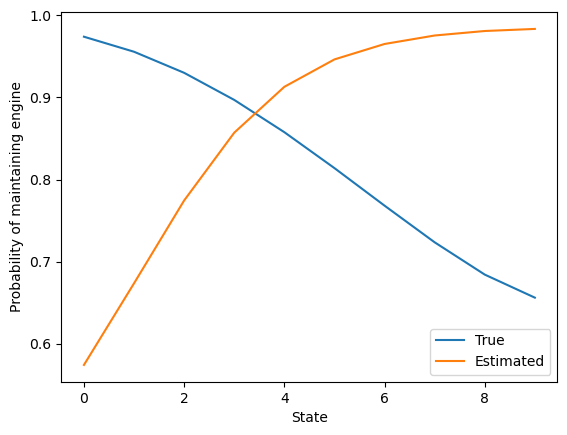

In [21]:
'''
Compute and Plot implied Choice Probabilities under true and estimated thetas
'''
# compute true and estimated value functions
umat_est = utility_matrix(dx, J, ccp_out.x)
primitive_est = dgp(β, umat_est, primitive_sim.F, dx, J)
v_sim_true = vfi(primitive_sim)
v_sim_est = vfi(primitive_est)

# compute true and estimated implied conditional probabilities
prob_true = prob_from_dgp(primitive_sim, v_sim_true)
prob_est = prob_from_dgp(primitive_est, v_sim_est)
prob_maintain_true = prob_true[:, 0]
prob_maintain_est = prob_est[:, 0]

# Plot
fig, ax = plt.subplots()  
xs = range(primitive_sim.dx)
ax.plot(xs, prob_maintain_true, label = 'True')
ax.plot(xs, prob_maintain_est, label = 'Estimated')
ax.set_xlabel('State') 
ax.set_ylabel('Probability of maintaining engine')
ax.legend()

# Exercise 1.4
Repeat the Part 3 using (i) nested fixed-point algorithm, (ii) nested pseudo-likelihood, and (iii)
MPEC (all of them are already coded-up in the Jupyter Notebook). Compare their speed and
accuracy for different values of the model parameters and discuss.

## Code from Notebook

### Nested fixed-point algorithm

The nested fixed-point algorithm (NFXP) contains two loops. 
- **Outer loop**: For a given vector of value functions $V$, find $\widehat\theta$ that maximizes the likelihood.
- **Inner loop**: For a given utility parameter $\theta$, find $\widehat{V}$ the fixed-point.

Here, we estimate the transition matrix first, and then take it as given when running NFXP. Hence, we will be maximizing the (partial) log-likelihood instead of the full log-likelihood.

The function to estimate the transition matrix is as follows

In [212]:
def likelihood_nfxp(θ, data, dgp):
    """The likelihood function for NFXP.
        
        Parameters
        ----------
        θ : `list`
            The utility parameters.
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
    """
    
    # Get value functions from parameters
    dgp_tmp = copy.copy(dgp)
    dgp_tmp.u = utility_matrix(dgp.dx, dgp.J, θ)
    V = vfi(dgp_tmp)
    
    # Get the choice probabilities
    pr0 = prob_from_dgp(dgp_tmp, V)
        
    # Compute likelihood of data
    l = likelihood(data, dgp_tmp, pr0)
    
    return l

def likelihood(data, dgp, prob):
    """The likelihood function with the given choice probability
    
        Parameters
        ----------
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
        prob : `ndarray`
            A matrix of choice probabilities.
    """
    
    # Compute likelihood of data
    N = int(max(data.i))
    T = int(max(data.t))
    l = 0.
    
    for i in range(N):
        for t in range(T):
            condn = (data.i == i + 1) & (data.t == t + 1)
            a = int(data.loc[condn].action)
            x = int(data.loc[condn].state)
            
            # Append the right probability depending on the choice and state
            l += np.log(prob[x, a]) 
            
    return -l/(N*T)

def nested_fixed_point(data, dgp):
    """The nested fixed-point algorithm.

        Parameters
        ----------
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
    """
    def ll(x):
        return likelihood_nfxp(x, data, dgp)
    θ = minimize(ll, [0.1, 0.1])
    
    return θ

### Nested pseudo-likelihood

- Consider a slightly different notion of value function here together with the assumption that the error term follows a mean-0 T1EV distribution:
  $$
    \overline{\overline{v}}(x_t; \theta, \varphi)
    = \sum_{j \in \mathcal{J}}
        \text{Pr}(a_t = j|x_t; \theta, \varphi)
        \left\{
            \overline{u}_j(x_t; \theta) 
            - \ln \mathrm{Pr}(a_t = j|x_t; \theta, \varphi)
            + \beta \sum_{x' \in \mathcal{X}}
                \overline{v}(x_{t+1} = x'; \theta, \varphi)
                \text{Pr}(x_{t+1} = x'|x_t, a_t = j; \varphi)
        \right\}.
  $$

- By stacking the terms over the states and actions, we obtain a matrix equation where
  $$
    \overline{\overline{v}}(x_t; \theta, \varphi)
    = [\mathbf{I} - \beta \mathbf{P}(x_{t+1}|x_t; \theta, \varphi)]^{-1}
    \mathbf{w}(a_t, x_t; \theta, \varphi),
  $$
  where
    - $\mathbf{w}(a_t, x_t; \theta, \varphi)
        := \begin{pmatrix}
            \mathbf{p}(a_t|1; \theta, \varphi)'(\overline{\mathbf{u}}(x_t = 1; \theta) - \ln \mathbf{p}(a_t|1; \theta, \varphi) \\ 
            \mathbf{p}(a_t|2; \theta, \varphi)'(\overline{\mathbf{u}}(x_t = 2; \theta) - \ln \mathbf{p}(a_t|2; \theta, \varphi) \\ 
            \vdots \\
            \mathbf{p}(a_t|X; \theta, \varphi)'(\overline{\mathbf{u}}(x_t = X; \theta) - \ln \mathbf{p}(a_t|X; \theta, \varphi) 
        \end{pmatrix}$.
    - $\mathbf{p}(a_t|1, \theta, \varphi)
          :=
          \begin{pmatrix}
              \text{Pr}(1|1; \theta, \varphi) \\ 
              \text{Pr}(2|1; \theta, \varphi) \\
              \vdots \\ 
              \text{Pr}(J|1; \theta, \varphi)
          \end{pmatrix}$.
    - $\mathbf{P}(x_{t+1}|1, a_t; \varphi)
          :=
          \begin{pmatrix}
             \text{Pr}(1|1,1;\varphi) & 
             \text{Pr}(2|1,1;\varphi) & 
             \cdots & 
             \text{Pr}(X|1,1;\varphi) \\ 
             \text{Pr}(1|1,2;\varphi) & 
             \text{Pr}(2|1,2;\varphi) & 
             \cdots & 
             \text{Pr}(X|1,2;\varphi) \\
             \vdots & \vdots & \ddots & \vdots \\
             \text{Pr}(1|1,J;\varphi) & 
             \text{Pr}(2|1,J;\varphi) & 
             \cdots & 
             \text{Pr}(X|1,J;\varphi) 
          \end{pmatrix}
          $.
- The $K$-stage policy iteration estimator works as follows. Let $\mathbf{P}^{K-1}(a_t|x_t; \theta, \widehat{\varphi})$ be the guess of $\mathbf{P}$ in the $(K-1)$-th step. With the given guess, we want to obtain
  $$
    \widehat{\theta}^K
    = \text{arg max}_{\theta} \prod_i
        \mathcal{L}_i\left(
            \Psi(
                \mathbf{P}^{K-1}(a_t|x_t; \theta, \widehat\varphi)
            )
        \right),
  $$
  where $\mathcal{L}_i(\cdot)$ denotes the likelihood induced by the argument. The second step is to update $\mathbf{P}$ via
  $$
    \mathbf{P}^K(a_t|x_t;\theta,\widehat{\varphi})
    = \Psi(\mathbf{P}^{K-1}(a_t|x_t; \widehat{\theta}^K, \widehat{\varphi}).
  $$

In [213]:
def estimate_unconditional_transition(dgp, phat):
    """Estimate the unconditional transition matrix.
    
        Parameters
        ----------
        dgp : `dgp`
            The primitives of the DDC model.
        phat : `ndarray`
            The matrix of estimated choice probabilities.
    """

    P = np.zeros((dgp.dx, dgp.dx))
    for a in range(dgp.J):
        P += dgp.F[a] * np.transpose([phat[:, a] for i in range(dgp.dx)])# Note: this is incorrect???
        
    return P

def nested_pseudo_likelihood_k(dgp, phat):
    """Step k of the nested pseudo likelihood method.
    
        Parameters
        ----------
        dgp : `dgp`
            The primitives of the DDC model.
        phat : `ndarray`
            The matrix of estimated choice probabilities.
    """
        
    # Get the "w" function
    what = np.sum(phat * (dgp.u - np.log(phat)), axis = 1)
    
    # Compute \bar{V} for the value function
    I = np.eye(dgp.dx)
    P = estimate_unconditional_transition(dgp, phat)
    inv_factor = np.linalg.inv(I - dgp.β * P)
    vbar = inv_factor @ what
    
    # Recover the choice-specific value function
    pnew = prob_from_dgp(dgp, vbar)
    
    return pnew
def likelihood_npl(θ, data, dgp, phat):
    """The likelihood function for the two-step method.
        
        Parameters
        ----------
        θ : `list`
            The utility parameters.
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
        phat : `ndarray`
            The matrix of estimated choice probabilities.
    """
    # Get the utility function based on the parameters
    dgp_tmp = copy.copy(dgp)
    dgp_tmp.u = utility_matrix(dgp.dx, dgp.J, θ)
    
    # Get the probability
    pk = nested_pseudo_likelihood_k(dgp_tmp, phat)
        
    # Compute likelihood of data
    l = likelihood(data, dgp_tmp, pk)
    
    return l

def nested_pseudo_likelihood(data, dgp, phat, K):
    """Run the nested pseudo likelihood method with K iterations.
        
        Parameters
        ----------
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
        phat : `ndarray`
            The matrix of estimated choice probabilities.
        K : `int`
            The number of iterations for the nested pseudo likelihood method.
    """
    
    pk = copy.copy(phat)
    dgpk = copy.copy(dgp)
    
    for i in range(K):
        
        def ll(x):
            return likelihood_npl(x, data, dgpk, pk)
        θiter = minimize(ll, [0.1, 0.1]).x
        
        dgpk.u = utility_matrix(dgp.dx, dgp.J, θiter)
        
        pk = nested_pseudo_likelihood_k(dgpk, pk)
        
        if i == K - 1:
            return pk, θiter

### MPEC
The problem can be implemented as a constrained optimization problem, where we maximize the likelihood subject to the value functions as constraints

In [214]:
def mpec(data, dgp):
    # Initial parameters
    dx = dgp.dx + 2
    
    # Define objective
    def mpec_objective(x):
        θ = x[range(2)]
        v = x[range(2, dx)]
        
        dgp_tmp = copy.copy(dgp)
        dgp_tmp.u = utility_matrix(dgp.dx, dgp.J, θ)

        prob = prob_from_dgp(dgp_tmp, v)
        ll = likelihood(data, dgp, prob)
        return ll
    
    # Define equality constraints
    def mpec_value_constraints(x):
        v = x[range(2, dx)]
        return v - vf(csvf(dgp, v))
    
    # Define lower bound on value functions
    def mpec_lb_constraint(x):
        v = x[range(2, dx)]
        return v
        
    # Dictionary of constraints
    c = [ {'type': 'eq', 'fun': mpec_value_constraints},
          {'type': 'ineq', 'fun': mpec_lb_constraint}]
        
    # Initial point
    x0 = np.concatenate((np.array([.1, .1]), np.zeros(dgp.dx)))
    
    return minimize_ipopt(mpec_objective, \
                          x0 = x0, \
                          constraints = c,
                          options = {"acceptable_tol": 1e-8})

#### Summary Function

In [215]:
def solve_ddc(data, dgp, method, K):
    """Solves a DDC model.
        
        Parameters
        ----------
        data : `DataFrame`
            The data that contains the actions and states.
        dgp : `dgp`
            The primitives of the DDC model.
        method : `string`
            The solution method.
        K : `int`
            The number of iterations for the nested pseudo likelihood method.
            This argument is used only when we use the "npl" method.
    """
    
    if method == "nfxp":
        out = nested_fixed_point(data, dgp)
    elif method == "two step":
        out = two_step_ccp(data, dgp)
    elif method == "npl":
        phat = estimate_ccp(data, dgp)
        out = nested_pseudo_likelihood(data, dgp, phat, K)
    elif method == "mpec":
        out = mpec(data, dgp)
    return out

## Our Code

In [216]:
'''
Write Function that
1) Takes in Thetas 
2) updates primitives
2) simulates data 
4) estimates theta using all methods
5) produces df with estimates, implied prob(maintain), time to compute
'''
# Set Parameters
β = 0.95
dx = 10
J = 2
methods = ["nfxp", "two step", "npl"] # need to add "mpec"

# create new utility matrix and value functions
umat_sim = utility_matrix(dx, J, θ_sim)
primitive_sim = dgp(β, umat_sim, F, dx, J)
v_sim = vfi(primitive_sim)

# Simulate new data
np.random.seed(1)
df = draw(primitive_sim, v_sim, N, T)

def solve_ddc_loop(thetas, K, N, T, f):
    '''
    Parameters
    ----------
    thetas : `list`
        list of theta pairs
    K : `int`
        The number of iterations for the nested pseudo likelihood method.
        This argument is used only when we use the "npl" method.
    N, T: 'scalar' 
        number of trucks and time periods to simulate, respectively
    f: 'array'
        transition probabilities in case of maintenence
    '''
    F = transition(f, dx)
    method_list = []
    theta_list = []
    estimate_list = []
    prob_list = []
    time_list = []

    for i in range(len(thetas)):
        # Updates Primitives, Simulate Data
        umat = utility_matrix(dx, J, thetas[i])
        primitive = dgp(β, umat, F, dx, J)
        v = vfi(primitive)
        np.random.seed(1)
        df = draw(primitive, v, N, T)
        primitive.F = estimate_transition(df, primitive)

        for method in methods:
            print(f"{thetas[i]},{method}")
            theta_list.append(thetas[i])
            method_list.append(method)
            
            # Estimate thetas
            start_time = time.perf_counter()
            est = solve_ddc(df, primitive, method, K)
            end_time = time.perf_counter()
            elapsed_time = end_time - start_time
            time_list.append(elapsed_time)
            
            if method == "npl":
                estimate_list.append(est[1])  
                prob_list.append(est[0][:, 0])  
            else:
                estimate_list.append(est.x)  
                
                # compute true and estimated implied conditional probabilities
                umat_est = utility_matrix(dx, J, est.x)
                primitive_est = dgp(β, umat_est, primitive.F, dx, J)
                v_est = vfi(primitive_est)
                prob_est = prob_from_dgp(primitive_est, v_est)
                prob_list.append(prob_est[:, 0])  
    
    result_df = pd.DataFrame({'theta': theta_list, 'method': method_list, 
                              'time': time_list, 'estimate': estimate_list,
                              'prob': prob_list})
    return result_df

In [218]:
thetas = [[-.1,3], [-.2,3] ,[-.3,3], [-.5,3],
          [-.1,5], [-.2,5] ,[-.3,5], [-.5,5]]

estimates_df = solve_ddc_loop(thetas,K=10, N=30, T=50, f=[.3,.6])
estimates_df

[-0.1, 3],nfxp


/var/folders/fl/c1k2q73j3wq12tnvvkmyj_qm0000gn/T/ipykernel_87883/446637203.py:48: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  a = int(data.loc[condn].action)
/var/folders/fl/c1k2q73j3wq12tnvvkmyj_qm0000gn/T/ipykernel_87883/446637203.py:49: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  x = int(data.loc[condn].state)


[-0.1, 3],two step
[-0.1, 3],npl
[-0.2, 3],nfxp


/var/folders/fl/c1k2q73j3wq12tnvvkmyj_qm0000gn/T/ipykernel_87883/446637203.py:48: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  a = int(data.loc[condn].action)
/var/folders/fl/c1k2q73j3wq12tnvvkmyj_qm0000gn/T/ipykernel_87883/446637203.py:49: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  x = int(data.loc[condn].state)


[-0.2, 3],two step
[-0.2, 3],npl
[-0.3, 3],nfxp


...

/var/folders/fl/c1k2q73j3wq12tnvvkmyj_qm0000gn/T/ipykernel_87883/446637203.py:48: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  a = int(data.loc[condn].action)
/var/folders/fl/c1k2q73j3wq12tnvvkmyj_qm0000gn/T/ipykernel_87883/446637203.py:49: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  x = int(data.loc[condn].state)


[-0.3, 5],two step
[-0.3, 5],npl
[-0.5, 5],nfxp


/var/folders/fl/c1k2q73j3wq12tnvvkmyj_qm0000gn/T/ipykernel_87883/446637203.py:48: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  a = int(data.loc[condn].action)
/var/folders/fl/c1k2q73j3wq12tnvvkmyj_qm0000gn/T/ipykernel_87883/446637203.py:49: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  x = int(data.loc[condn].state)


[-0.5, 5],two step
[-0.5, 5],npl


,theta,method,time,estimate,prob
0,"[-0.1, 3]",nfxp,14.170218,"[-0.10295618502381378, 3.0011792520532703]","[0.9368829587183467, 0.9050534117729544, 0.866..."
1,"[-0.1, 3]",two step,9.777607,"[-0.11428423875401413, 2.956137023276188]","[0.9332194935784822, 0.8973959100648616, 0.853..."
2,"[-0.1, 3]",npl,92.178401,"[-0.10295587521890671, 3.001175589318091]","[0.9368827961110755, 0.9050532848778093, 0.866..."
3,"[-0.2, 3]",nfxp,14.107535,"[-0.20612780994038604, 2.9561230971969636]","[0.9245096578422076, 0.8620488177859514, 0.781..."
4,"[-0.2, 3]",two step,8.062250,"[-0.218405472305414, 2.8911410084000053]","[0.9194718504512848, 0.8517278019269723, 0.764..."
5,"[-0.2, 3]",npl,67.009048,"[-0.20613722331778672, 2.956238123303788]","[0.9245158194051946, 0.8620550989068042, 0.781..."
6,"[-0.3, 3]",nfxp,14.919784,"[-0.3334503844030422, 3.136480517738577]","[0.9259579831366591, 0.8324389813031482, 0.703..."
7,"[-0.3, 3]",two step,7.434557,"[-0.3423135687996218, 3.0810281637636594]","[0.9221846982009441, 0.8241747509226154, 0.691..."
8,"[-0.3, 3]",npl,75.965788,"[-0.333453512932662, 3.136542954850888]","[0.9259613560703345, 0.832443642769769, 0.7039..."
9,"[-0.5, 3]",nfxp,14.273226,"[-0.5229776183320716, 3.010883031349585]","[0.9082758769130452, 0.7536500816182427, 0.553..."


In [ ]:
# Plot
theta_plot = [[-.2,3], [-.3,3], [-.2,5], [-.3,5]]
dx = 10
theta = [-.2,3]

for theta in theta_plot:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    # Estimate and plot true transition probabilities
    umat_true = utility_matrix(dx, J, theta)
    primitive_true = dgp(β, umat_true, F, dx, J)
    v_true= vfi(primitive_true)
    prob_true = prob_from_dgp(primitive_true, v_true)
    ax.plot(range(dx), prob_true[:, 0], linewidth=2, label='True', marker='o',zorder=1)


    #Get estimated probabilities
    data = estimates_df[estimates_df['theta'].apply(lambda x: x == theta)].copy()
        # Convert the array column into separate columns
    prob_expanded = pd.DataFrame(data['prob'].tolist(), 
                             columns=[f'state_{i}' for i in range(dx)])
    data = pd.concat([data.drop('prob', axis=1).reset_index(drop=True), 
                            prob_expanded.reset_index(drop=True)], axis=1)

         # Reshape to long format
    data = data.melt(
        id_vars=['theta', 'method', 'time', 'estimate'],  
        value_vars=[f'state_{i}' for i in range(dx)],     
        var_name='state',                                  
        value_name='prob'                                 
)
    data['state'] = data['state'].str.replace('state_', '').astype(int)
    
    style = {
    "nfxp": {"linestyle": "-",  "marker": "o", "zorder": 4,"alpha": 0.5},
    "npl":  {"linestyle": "--", "marker": "s", "zorder": 3,"alpha": 0.7},
    "two step": {"linestyle": "-.", "marker": "D", "zorder": 2,"alpha": 0.7},
}
    
    # Plot each method
    for method in data['method'].unique():
        method_data = data[data['method'] == method]
        ax.plot(method_data['state'], method_data['prob'], 
               label=method, linewidth=2, **style[method])
    
    # Formatting
    ax.set_xlabel('State')
    ax.set_ylabel('Probability of Maintain')
    ax.set_title(f'Estimated vs True CCPs for θ = {theta}')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()



In [263]:
estimates_df['diff'] = np.abs(estimates_df['theta'].values - estimates_df['estimate'].values)
estimates_df.groupby('method')['diff'].mean()


method
nfxp        [0.01717346436923267, 0.17175430113815832]
npl           [0.0171755126192167, 0.1717482070682665]
two step    [0.025432066311166568, 0.2173729199092077]
Name: diff, dtype: object

In [264]:
estimates_df.groupby('method')['time'].mean()

method
nfxp        15.070124
npl         88.490697
two step     9.068452
Name: time, dtype: float64